In [3]:
import os, sys, time, copy, random
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision, torchvision.transforms as T
from torch.utils.data import DataLoader, Subset

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

FAST = device.type != "cpu"   # fewer epochs on CPU
EP_SCRATCH, EP_HEAD, EP_FT = (10, 5, 6) if FAST else (5, 3, 3)

print("PyTorch:", torch.__version__, "| torchvision:", torchvision.__version__)
print("Training on:", device, "| epochs (scratch/head/fine-tune):", EP_SCRATCH, EP_HEAD, EP_FT)

PyTorch: 2.9.1 | torchvision: 0.24.1
Training on: mps | epochs (scratch/head/fine-tune): 10 5 6


In [9]:
NW = 0   # DataLoader workers (0 avoids multiprocessing errors in Jupyter on Mac)
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']
CIFAR_MEAN, CIFAR_STD = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)   # Week 3 values
IMNET_MEAN, IMNET_STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)         # what ResNet saw
IMG = 64            # ResNet input size (CIFAR is 32x32)
root = "./data"

# Pretrained backbones need ImageNet statistics, not the CIFAR ones from Week 3
eval_tf = T.Compose([T.Resize(IMG), T.ToTensor(), T.Normalize(IMNET_MEAN, IMNET_STD)])
aug_tf  = T.Compose([T.RandomResizedCrop(IMG, scale=(0.7, 1.0), ratio=(0.9, 1.1)),
                     T.RandomHorizontalFlip(),
                     T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
                     T.ToTensor(), T.Normalize(IMNET_MEAN, IMNET_STD)])

ds_eval = torchvision.datasets.CIFAR10(root, train=True,  download=True,  transform=eval_tf)
ds_aug  = torchvision.datasets.CIFAR10(root, train=True,  download=False, transform=aug_tf)
ds_test = torchvision.datasets.CIFAR10(root, train=False, download=True,  transform=eval_tf)

# 500 train + 100 validation images per class, chosen without overlap
targets = np.array(ds_eval.targets)
rng = np.random.default_rng(SEED)
train_idx, val_idx = [], []
for c in range(10):
    idx = rng.permutation(np.where(targets == c)[0])
    train_idx += idx[:500].tolist()
    val_idx   += idx[500:600].tolist()

assert len(set(train_idx) & set(val_idx)) == 0, "LEAKAGE: train and val overlap!"
print("train:", len(train_idx), "| val:", len(val_idx), "| test:", len(ds_test))
print("images per class in train:", np.bincount(targets[train_idx]))

def make_loader(ds, idx, shuffle, bs=64):
    return DataLoader(Subset(ds, idx), batch_size=bs, shuffle=shuffle, num_workers=NW)

train_plain = make_loader(ds_eval, train_idx, True)        # no augmentation
train_aug   = make_loader(ds_aug,  train_idx, True)        # with augmentation
val_loader  = make_loader(ds_eval, val_idx, False, 128)
test_loader = DataLoader(ds_test, batch_size=128, shuffle=False, num_workers=NW)

train: 5000 | val: 1000 | test: 10000
images per class in train: [500 500 500 500 500 500 500 500 500 500]


In [13]:
ce = nn.CrossEntropyLoss()

def trainable(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

def set_train_mode(model):
    model.train()
    for m in model.modules():   # keep frozen BatchNorm layers in eval mode
        if isinstance(m, nn.BatchNorm2d) and not any(p.requires_grad for p in m.parameters()):
            m.eval()

def run_epoch(model, loader, optimizer=None, criterion=ce):
    training = optimizer is not None
    if training:
        set_train_mode(model)
    else:
        model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            n += x.size(0)
    return total_loss / n, correct / n

def fit(model, optimizer, train_loader, val_loader, epochs, tag, criterion=ce):
    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for ep in range(1, epochs + 1):
        t0 = time.time()
        tl, ta = run_epoch(model, train_loader, optimizer, criterion)
        vl, va = run_epoch(model, val_loader)
        for k, v in zip(hist, (tl, vl, ta, va)):
            hist[k].append(v)
        print(f"[{tag}] epoch {ep}/{epochs} | train {ta:.1%} (loss {tl:.3f}) "
              f"| val {va:.1%} (loss {vl:.3f}) | {time.time() - t0:.0f}s")
    return hist

@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    probs, ys = [], []
    for x, y in loader:
        probs.append(F.softmax(model(x.to(device)), dim=1).cpu())
        ys.append(y)
    return torch.cat(probs), torch.cat(ys)

def confusion(ys, preds, n=10):
    cm = np.zeros((n, n), dtype=int)   # rows = true, cols = predicted
    for t, p_ in zip(ys.numpy(), preds.numpy()):
        cm[t, p_] += 1
    return cm

In [15]:
class SceneCNN(nn.Module):   # identical to Week 3
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128 * 4 * 4, 256), nn.ReLU(), nn.Linear(256, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x))

w3_tf = T.Compose([T.ToTensor(), T.Normalize(CIFAR_MEAN, CIFAR_STD)])
w3_train = torchvision.datasets.CIFAR10(root, train=True,  download=False, transform=w3_tf)
w3_test  = torchvision.datasets.CIFAR10(root, train=False, download=False, transform=w3_tf)
w3_train_loader = make_loader(w3_train, train_idx, True)
w3_val_loader   = make_loader(w3_train, val_idx, False, 128)
w3_test_loader  = DataLoader(w3_test, batch_size=128, shuffle=False, num_workers=NW)

# Optional: how good was your Week 3 model (trained on 45,000 images)?
if os.path.exists("scene_cnn_week3.pth"):
    old = SceneCNN().to(device)
    old.load_state_dict(torch.load("scene_cnn_week3.pth", map_location=device))
    _, old_acc = run_epoch(old, w3_test_loader)
    print(f"Week 3 model (45,000 training images) test accuracy: {old_acc:.1%}")
else:
    print("scene_cnn_week3.pth not found: skipping (your Week 3 result was roughly 70-75%)")

Week 3 model (45,000 training images) test accuracy: 74.3%


In [17]:
scratch = SceneCNN().to(device)
opt = torch.optim.SGD(scratch.parameters(), lr=0.01, momentum=0.9)
hist_scratch = fit(scratch, opt, w3_train_loader, w3_val_loader, EP_SCRATCH, "scratch")

[scratch] epoch 1/10 | train 15.5% (loss 2.247) | val 24.1% (loss 2.057) | 4s
[scratch] epoch 2/10 | train 30.8% (loss 1.918) | val 33.1% (loss 1.818) | 1s
[scratch] epoch 3/10 | train 40.4% (loss 1.656) | val 42.5% (loss 1.625) | 1s
[scratch] epoch 4/10 | train 43.9% (loss 1.550) | val 46.6% (loss 1.544) | 1s
[scratch] epoch 5/10 | train 48.9% (loss 1.429) | val 48.8% (loss 1.437) | 1s
[scratch] epoch 6/10 | train 52.9% (loss 1.297) | val 48.9% (loss 1.415) | 1s
[scratch] epoch 7/10 | train 56.8% (loss 1.201) | val 54.2% (loss 1.279) | 1s
[scratch] epoch 8/10 | train 61.1% (loss 1.071) | val 54.2% (loss 1.321) | 1s
[scratch] epoch 9/10 | train 63.2% (loss 1.034) | val 56.2% (loss 1.241) | 1s
[scratch] epoch 10/10 | train 69.7% (loss 0.860) | val 51.7% (loss 1.402) | 1s


In [19]:
def make_resnet(dropout=0.0):
    m = torchvision.models.resnet18(weights="IMAGENET1K_V1")   # downloads ~45 MB the first time
    for p in m.parameters():
        p.requires_grad = False                                  # freeze everything
    m.fc = nn.Sequential(nn.Dropout(dropout),                    # new head: trainable by default
                         nn.Linear(m.fc.in_features, 10))
    return m.to(device)

fe_model = make_resnet(dropout=0.0)
total = sum(p.numel() for p in fe_model.parameters())
print(f"Total parameters    : {total:,}")
print(f"Trainable parameters: {trainable(fe_model):,} ({trainable(fe_model) / total:.2%})")
print("Head:", fe_model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/marufi/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:04<00:00, 9.94MB/s]


Total parameters    : 11,181,642
Trainable parameters: 5,130 (0.05%)
Head: Sequential(
  (0): Dropout(p=0.0, inplace=False)
  (1): Linear(in_features=512, out_features=10, bias=True)
)


In [21]:
opt = torch.optim.AdamW([p for p in fe_model.parameters() if p.requires_grad],
                        lr=1e-3, weight_decay=1e-2)
hist_fe = fit(fe_model, opt, train_plain, val_loader, EP_HEAD, "feature-extraction")

[feature-extraction] epoch 1/5 | train 52.2% (loss 1.382) | val 67.0% (loss 0.958) | 4s
[feature-extraction] epoch 2/5 | train 70.5% (loss 0.866) | val 69.6% (loss 0.877) | 2s
[feature-extraction] epoch 3/5 | train 73.7% (loss 0.771) | val 71.7% (loss 0.840) | 2s
[feature-extraction] epoch 4/5 | train 75.9% (loss 0.703) | val 71.7% (loss 0.848) | 2s
[feature-extraction] epoch 5/5 | train 77.4% (loss 0.663) | val 72.6% (loss 0.828) | 2s


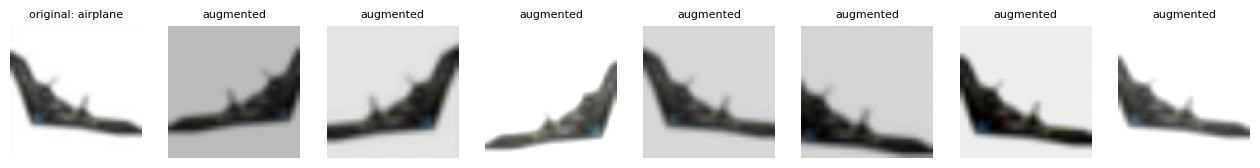

In [23]:
def denorm(x):
    m = torch.tensor(IMNET_MEAN).view(3, 1, 1); s = torch.tensor(IMNET_STD).view(3, 1, 1)
    return (x * s + m).clamp(0, 1)

raw = torchvision.datasets.CIFAR10(root, train=True, download=False)   # PIL images
img, label = raw[train_idx[3]]
fig, axes = plt.subplots(1, 8, figsize=(16, 2.4))
axes[0].imshow(img.resize((IMG, IMG))); axes[0].set_title("original: " + CLASSES[label], fontsize=8)
for ax in axes[1:]:
    ax.imshow(denorm(aug_tf(img)).permute(1, 2, 0)); ax.set_title("augmented", fontsize=8)
for ax in axes:
    ax.axis("off")
plt.show()

In [25]:
ft_model = copy.deepcopy(fe_model)       # start from the trained head
for p in ft_model.layer4.parameters():
    p.requires_grad = True               # unfreeze the last block
ft_model.fc[0].p = 0.3                   # 30% dropout in front of the classifier

opt = torch.optim.AdamW([
    {"params": ft_model.layer4.parameters(), "lr": 1e-4},   # pretrained: gentle
    {"params": ft_model.fc.parameters(),     "lr": 1e-3},   # new head: faster
], weight_decay=1e-2)

total = sum(p.numel() for p in ft_model.parameters())
print(f"Trainable parameters: {trainable(ft_model):,} of {total:,} ({trainable(ft_model) / total:.0%})")

Trainable parameters: 8,398,858 of 11,181,642 (75%)


In [27]:
hist_ft = fit(ft_model, opt, train_aug, val_loader, EP_FT, "fine-tune")


[fine-tune] epoch 1/6 | train 65.2% (loss 1.016) | val 74.8% (loss 0.772) | 5s
[fine-tune] epoch 2/6 | train 76.8% (loss 0.687) | val 75.9% (loss 0.711) | 4s
[fine-tune] epoch 3/6 | train 81.5% (loss 0.516) | val 77.5% (loss 0.700) | 4s
[fine-tune] epoch 4/6 | train 84.8% (loss 0.423) | val 77.6% (loss 0.691) | 4s
[fine-tune] epoch 5/6 | train 87.6% (loss 0.346) | val 78.4% (loss 0.692) | 4s
[fine-tune] epoch 6/6 | train 89.7% (loss 0.295) | val 78.7% (loss 0.712) | 4s


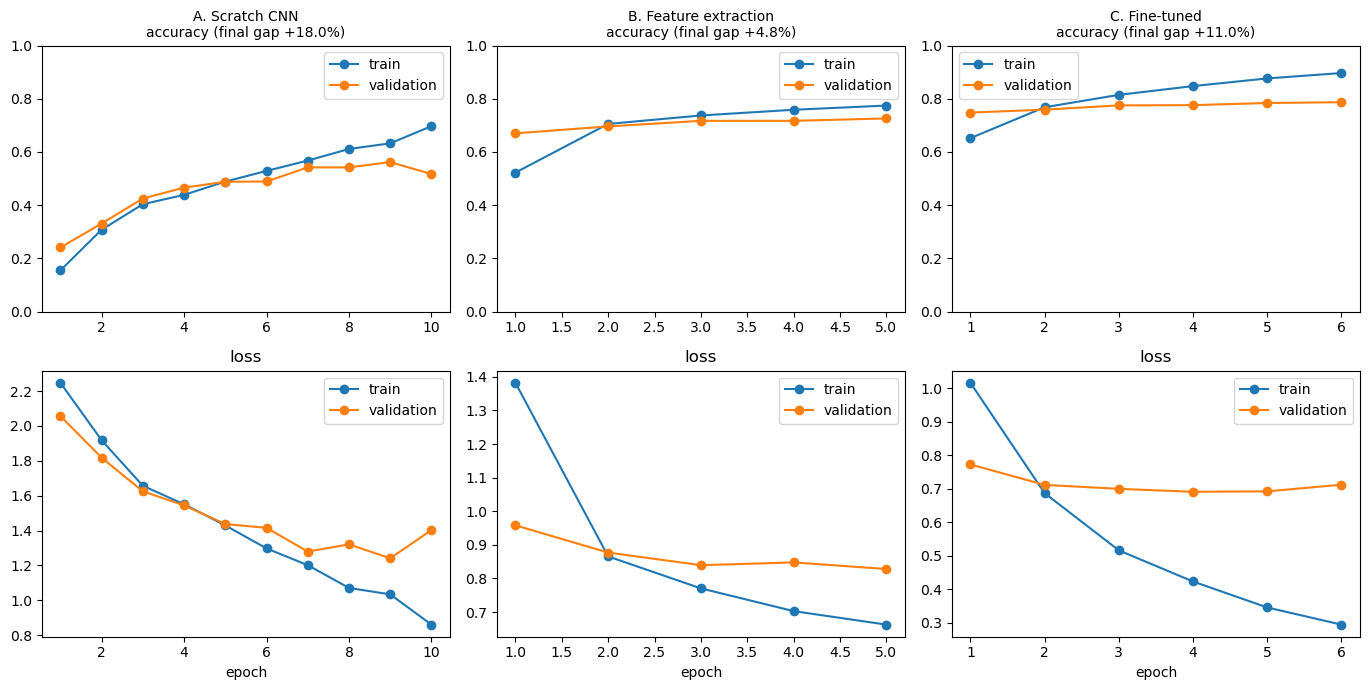

In [29]:
def plot_curves(hists):
    fig, axes = plt.subplots(2, len(hists), figsize=(4.6 * len(hists), 7), squeeze=False)
    for j, (name, h) in enumerate(hists.items()):
        e = range(1, len(h["val_acc"]) + 1)
        gap = h["train_acc"][-1] - h["val_acc"][-1]
        axes[0, j].plot(e, h["train_acc"], "o-", label="train")
        axes[0, j].plot(e, h["val_acc"], "o-", label="validation")
        axes[0, j].set_ylim(0, 1); axes[0, j].legend()
        axes[0, j].set_title(f"{name}\naccuracy (final gap {gap:+.1%})", fontsize=10)
        axes[1, j].plot(e, h["train_loss"], "o-", label="train")
        axes[1, j].plot(e, h["val_loss"], "o-", label="validation")
        axes[1, j].set_xlabel("epoch"); axes[1, j].set_title("loss"); axes[1, j].legend()
    plt.tight_layout(); plt.show()

plot_curves({"A. Scratch CNN": hist_scratch,
             "B. Feature extraction": hist_fe,
             "C. Fine-tuned": hist_ft})

In [31]:
rows = [("A. Scratch CNN",          scratch,  w3_test_loader, hist_scratch),
        ("B. Feature extraction",   fe_model, test_loader,    hist_fe),
        ("C. Fine-tuned ResNet-18", ft_model, test_loader,    hist_ft)]

print(f"{'Model':<26}{'trainable params':>18}{'val acc':>10}{'test acc':>10}")
test_acc = {}
for name, m, loader, h in rows:
    _, acc = run_epoch(m, loader)
    test_acc[name] = acc
    print(f"{name:<26}{trainable(m):>18,}{h['val_acc'][-1]:>10.1%}{acc:>10.1%}")

Model                       trainable params   val acc  test acc
A. Scratch CNN                       620,362     51.7%     50.7%
B. Feature extraction                  5,130     72.6%     71.8%
C. Fine-tuned ResNet-18            8,398,858     78.7%     77.8%


In [33]:
probs, ys = predict_all(ft_model, test_loader)
preds = probs.argmax(1)
cm = confusion(ys, preds)
prec = cm.diagonal() / np.maximum(cm.sum(0), 1)
rec  = cm.diagonal() / np.maximum(cm.sum(1), 1)
f1   = 2 * prec * rec / np.maximum(prec + rec, 1e-9)

probs_s, ys_s = predict_all(scratch, w3_test_loader)
rec_s = confusion(ys_s, probs_s.argmax(1)).diagonal() / 1000

print(f"{'class':<11}{'precision':>10}{'recall':>8}{'F1':>7}{'recall (scratch)':>18}{'gain':>8}")
for i, c in enumerate(CLASSES):
    print(f"{c:<11}{prec[i]:>10.1%}{rec[i]:>8.1%}{f1[i]:>7.2f}{rec_s[i]:>18.1%}{rec[i] - rec_s[i]:>+8.1%}")
print(f"\nmacro-F1 (fine-tuned): {f1.mean():.3f}")

off = cm.copy(); np.fill_diagonal(off, 0)
print("\nThree most common mistakes of the fine-tuned model:")
for idx in np.argsort(-off.ravel())[:3]:
    t, p_ = divmod(idx, 10)
    print(f"  {CLASSES[t]} predicted as {CLASSES[p_]}: {off[t, p_]} times")

class       precision  recall     F1  recall (scratch)    gain
airplane        74.0%   86.8%   0.80             75.1%  +11.7%
automobile      84.4%   86.5%   0.85             55.3%  +31.2%
bird            74.7%   68.0%   0.71             67.7%   +0.3%
cat             67.1%   57.7%   0.62             49.0%   +8.7%
deer            73.6%   72.0%   0.73             21.7%  +50.3%
dog             67.4%   75.5%   0.71             23.0%  +52.5%
frog            73.0%   87.7%   0.80             45.4%  +42.3%
horse           88.3%   74.3%   0.81             42.5%  +31.8%
ship            90.7%   85.4%   0.88             70.9%  +14.5%
truck           88.5%   83.9%   0.86             56.7%  +27.2%

macro-F1 (fine-tuned): 0.777

Three most common mistakes of the fine-tuned model:
  cat predicted as dog: 195 times
  dog predicted as cat: 113 times
  truck predicted as automobile: 93 times


In [35]:
VEHICLES = torch.tensor([0, 1, 8, 9])   # airplane, automobile, ship, truck
true_v, pred_v = torch.isin(ys, VEHICLES), torch.isin(preds, VEHICLES)
print(f"10-class (object-level) accuracy : {(preds == ys).float().mean():.2%}")
print(f"Vehicle vs animal (scene-level)  : {(true_v == pred_v).float().mean():.2%}")
animal_as_vehicle = ((~true_v) & pred_v).sum().item() / (~true_v).sum().item()
print(f"Animals mistaken for vehicles    : {animal_as_vehicle:.1%}  <- the costly error for a deer warning")

10-class (object-level) accuracy : 77.78%
Vehicle vs animal (scene-level)  : 96.32%
Animals mistaken for vehicles    : 3.8%  <- the costly error for a deer warning


In [37]:
def val_acc_with(transform):
    ds = torchvision.datasets.CIFAR10(root, train=True, download=False, transform=transform)
    loader = DataLoader(Subset(ds, val_idx), batch_size=128, shuffle=False, num_workers=NW)
    return run_epoch(ft_model, loader)[1]

variants = {
    "ImageNet stats (correct)":   T.Compose([T.Resize(IMG), T.ToTensor(), T.Normalize(IMNET_MEAN, IMNET_STD)]),
    "CIFAR stats (close, wrong)": T.Compose([T.Resize(IMG), T.ToTensor(), T.Normalize(CIFAR_MEAN, CIFAR_STD)]),
    "No normalisation (0..1)":    T.Compose([T.Resize(IMG), T.ToTensor()]),
}
for name, tf_ in variants.items():
    print(f"{name:<30} validation accuracy = {val_acc_with(tf_):.1%}")

ImageNet stats (correct)       validation accuracy = 78.7%
CIFAR stats (close, wrong)     validation accuracy = 77.4%
No normalisation (0..1)        validation accuracy = 48.5%


In [39]:
DEER = CLASSES.index("deer")
imb_idx = [i for i in train_idx if targets[i] != DEER] + \
          [i for i in train_idx if targets[i] == DEER][:25]
counts = np.bincount(targets[imb_idx], minlength=10)
weights = torch.tensor(counts.sum() / (10 * counts), dtype=torch.float32).to(device)
print("training counts:", counts)

def train_variant(criterion, tag):
    m = copy.deepcopy(fe_model)   # same starting point for both runs
    for p in m.layer4.parameters():
        p.requires_grad = True
    o = torch.optim.AdamW([{"params": m.layer4.parameters(), "lr": 1e-4},
                           {"params": m.fc.parameters(),     "lr": 1e-3}], weight_decay=1e-2)
    fit(m, o, make_loader(ds_aug, imb_idx, True), val_loader, 4, tag, criterion)
    pr, y = predict_all(m, val_loader)
    return (pr.argmax(1) == y)[y == DEER].float().mean().item()   # recall of deer

print("deer recall, plain loss   :", f"{train_variant(ce, 'plain'):.1%}")
print("deer recall, weighted loss:", f"{train_variant(nn.CrossEntropyLoss(weight=weights), 'weighted'):.1%}")

training counts: [500 500 500 500  25 500 500 500 500 500]
[plain] epoch 1/4 | train 71.4% (loss 0.846) | val 68.1% (loss 0.956) | 4s
[plain] epoch 2/4 | train 83.0% (loss 0.509) | val 69.6% (loss 0.929) | 3s
[plain] epoch 3/4 | train 87.1% (loss 0.373) | val 70.3% (loss 0.933) | 4s
[plain] epoch 4/4 | train 90.8% (loss 0.262) | val 72.5% (loss 0.875) | 4s
deer recall, plain loss   : 11.0%
[weighted] epoch 1/4 | train 68.3% (loss 1.024) | val 71.8% (loss 0.830) | 4s
[weighted] epoch 2/4 | train 78.9% (loss 0.591) | val 74.0% (loss 0.782) | 3s
[weighted] epoch 3/4 | train 84.2% (loss 0.436) | val 72.8% (loss 0.823) | 4s
[weighted] epoch 4/4 | train 87.9% (loss 0.348) | val 74.0% (loss 0.825) | 4s
deer recall, weighted loss: 36.0%
